In [2]:
import pandas as pd

df = pd.read_csv('labs/lab3/titanic_filled.csv')
df['Pclass'] = df['Pclass'].astype('category')
df['Sex'] = df['Sex'].astype('category')
df['Embarked'] = df['Embarked'].astype('category')

# Drop unnamed (the first column)
df = df.drop(columns=['Unnamed: 0'])

df.head()


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Age_fill_mean,Age_fill_median,Age_fill_mode,Age_fill_KNN
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,22.0,22.0,22.0,22.0
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,38.0,38.0,38.0,38.0
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,26.0,26.0,26.0,26.0
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,35.0,35.0,35.0,35.0
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,35.0,35.0,35.0,35.0


### For each variable in the data set, identify the type of the data it contains and articulate the reason for your assessment. Refer to the typology from the data types lecture.

**1. PassengerId (Integer/Identifier)**
- **Type**: Nominal categorical (identifier)
- **Reason**: Sequential integer values used purely for unique identification. No mathematical operations are meaningful; higher PassengerId doesn't mean "more" of anything. Functions as a label/key.

**2. Survived (Integer/Binary)**
- **Type**: Nominal categorical (binary)
- **Reason**: Binary outcome variable (0 = did not survive, 1 = survived). Numbers are labels for categories with no inherent ordering or magnitude. Could equivalently be "No/Yes" or "Dead/Alive".

**3. Pclass (Integer/Ordinal Categorical)**
- **Type**: Ordinal categorical
- **Reason**: Passenger class (1 = first, 2 = second, 3 = third) has a natural ordering. First class > second class > third class in terms of luxury and cost. However, the numeric difference between classes is not meaningful (the difference between 1st and 2nd is not "equal" to the difference between 2nd and 3rd).

**4. Name (String/Text)**
- **Type**: Nominal categorical (text identifier)
- **Reason**: Unique text strings identifying passengers. Contains structured information (title, surname, given name) but treated as identifier. No ordering or numeric properties.

**5. Sex (String/Categorical)**
- **Type**: Nominal categorical
- **Reason**: Binary categorical variable representing biological sex (male/female). Two distinct categories with no inherent ordering or ranking. Categories are labels only.

**6. Age (Float/Continuous)**
- **Type**: Ratio continuous
- **Reason**: Quantitative measurement with meaningful zero point (age 0 = birth). Differences and ratios are meaningful (age 40 is twice age 20). Can take any positive real value including decimals. Has missing values in original data.

**7. SibSp (Integer/Discrete Count)**
- **Type**: Ratio discrete
- **Reason**: Count of siblings/spouses aboard. Non-negative integers representing discrete quantities. Zero is meaningful (no siblings/spouses). Ratios make sense (2 siblings is twice 1 sibling). Cannot be fractional.

**8. Parch (Integer/Discrete Count)**
- **Type**: Ratio discrete
- **Reason**: Count of parents/children aboard. Similar to SibSp - discrete non-negative integers representing quantities. Has true zero and meaningful ratios.

**9. Ticket (String/Categorical)**
- **Type**: Nominal categorical (mixed alphanumeric identifier)
- **Reason**: Alphanumeric ticket numbers/codes. Although some are purely numeric, they function as identifiers/labels rather than quantities. No ordering or mathematical operations are meaningful.

**10. Fare (Float/Continuous)**
- **Type**: Ratio continuous
- **Reason**: Monetary amount paid in British pounds. Continuous quantitative variable with true zero (could theoretically pay £0). Differences and ratios are meaningful. Can take any non-negative real value.

**11. Cabin (String/Categorical)**
- **Type**: Nominal categorical (with potential ordinal structure)
- **Reason**: Cabin designation (e.g., "C85", "B96"). Primarily categorical labels, though deck letter (A-G) has ordinal properties (deck location). High percentage of missing values. Could be decomposed into deck (ordinal) and cabin number (nominal).

**12. Embarked (String/Categorical)**
- **Type**: Nominal categorical
- **Reason**: Port of embarkation with three categories (C = Cherbourg, Q = Queenstown, S = Southampton). No natural ordering among ports - they are simply different locations.

**13-16. Age_fill_mean, Age_fill_median, Age_fill_mode, Age_fill_KNN (Float/Continuous)**
- **Type**: Ratio continuous (imputed versions)
- **Reason**: These are imputed versions of the Age variable using different methods (mean, median, mode, and K-Nearest Neighbors). They retain the same data type as Age - continuous ratio measurements. The imputation method affects the distribution but not the fundamental data type.

**Summary of Data Type Distribution:**
- **Nominal Categorical**: PassengerId, Survived, Name, Sex, Ticket, Cabin, Embarked (7 variables)
- **Ordinal Categorical**: Pclass (1 variable)
- **Ratio Discrete**: SibSp, Parch (2 variables)
- **Ratio Continuous**: Age, Fare, Age_fill_mean, Age_fill_median, Age_fill_mode, Age_fill_KNN (6 variables)

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid")

df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked', 'Age_fill_mean',
       'Age_fill_median', 'Age_fill_mode', 'Age_fill_KNN'],
      dtype='str')

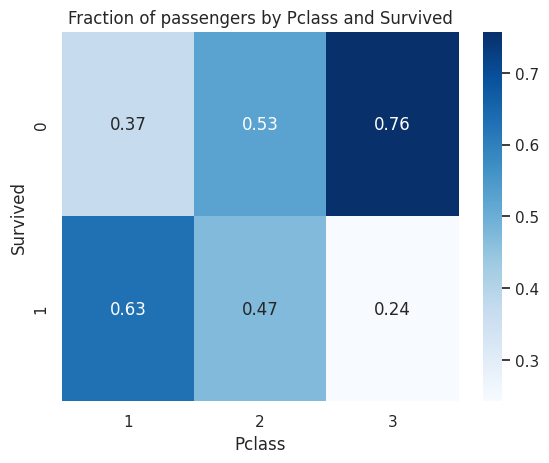

Pclass
1    1.0
2    1.0
3    1.0
dtype: float64

In [5]:
# 2. Heatmap: Pclass vs Survived (fraction per class)
pclass_counts = df.pivot_table(index="Survived", columns="Pclass", values="PassengerId", aggfunc="count")
pclass_frac = pclass_counts / pclass_counts.sum(axis=0)

ax = sns.heatmap(pclass_frac, annot=True, fmt=".2f", cmap="Blues")
ax.set_title("Fraction of passengers by Pclass and Survived")
ax.set_xlabel("Pclass")
ax.set_ylabel("Survived")
plt.show()

# Check: each column should sum to 1
pclass_frac.sum(axis=0)

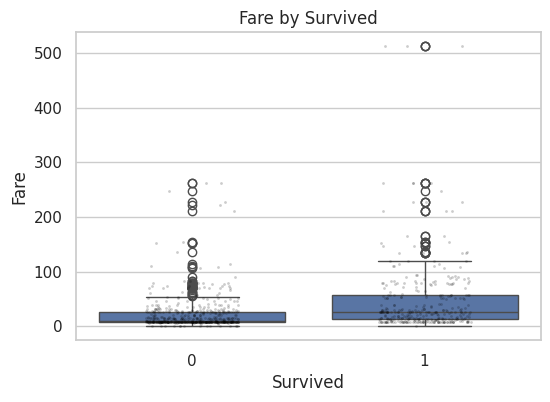

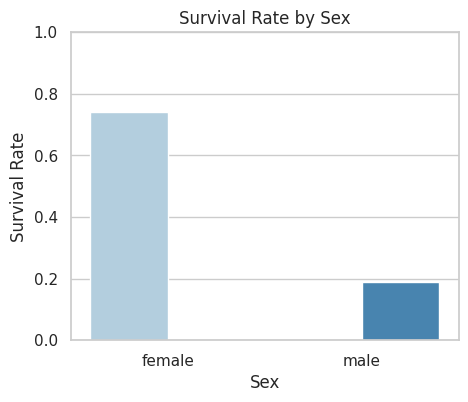

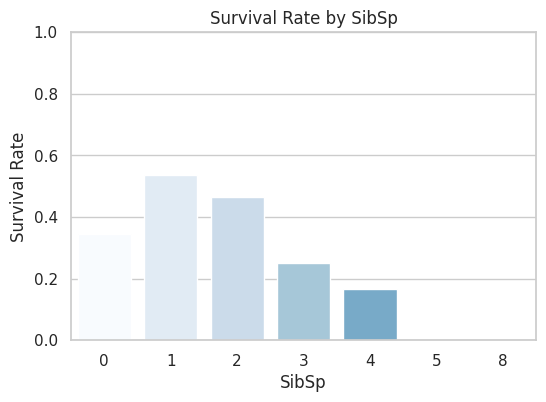

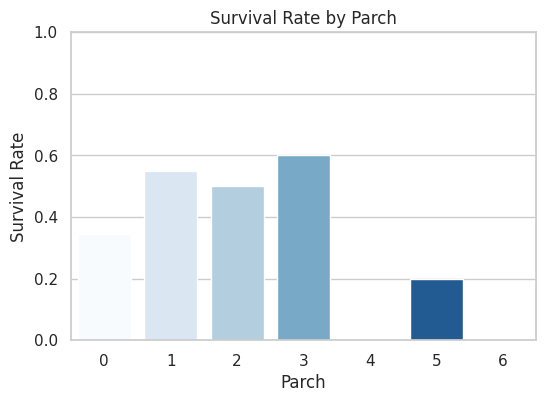

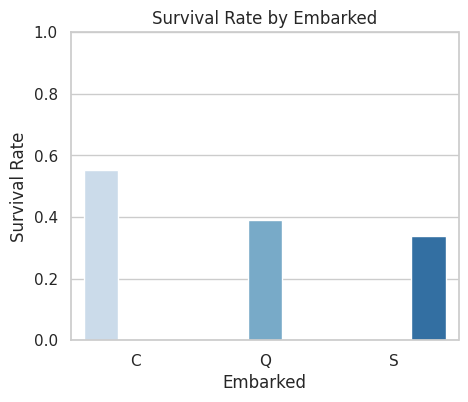

In [7]:
# 3-4. Visualizations for Fare, Sex, SibSp, Parch, Embarked vs Survived

# Fare (continuous) vs Survived: boxplot + strip for distribution
plt.figure(figsize=(6, 4))
sns.boxplot(data=df, x="Survived", y="Fare")
sns.stripplot(data=df, x="Survived", y="Fare", color="black", alpha=0.2, jitter=0.2, size=2)
plt.title("Fare by Survived")
plt.show()

# Sex (categorical) vs Survived: survival rate bar
sex_rate = df.pivot_table(index="Sex", values="Survived", aggfunc="mean").sort_values("Survived", ascending=False)
plt.figure(figsize=(5, 4))
sns.barplot(x=sex_rate.index, y=sex_rate["Survived"], hue=sex_rate.index, legend=False, palette="Blues")
plt.ylim(0, 1)
plt.title("Survival Rate by Sex")
plt.ylabel("Survival Rate")
plt.show()

# SibSp (discrete) vs Survived: survival rate bar
sib_rate = df.pivot_table(index="SibSp", values="Survived", aggfunc="mean")
plt.figure(figsize=(6, 4))
sns.barplot(x=sib_rate.index, y=sib_rate["Survived"], hue=sib_rate.index, legend=False, palette="Blues")
plt.ylim(0, 1)
plt.title("Survival Rate by SibSp")
plt.ylabel("Survival Rate")
plt.show()

# Parch (discrete) vs Survived: survival rate bar
parch_rate = df.pivot_table(index="Parch", values="Survived", aggfunc="mean")
plt.figure(figsize=(6, 4))
sns.barplot(x=parch_rate.index, y=parch_rate["Survived"], hue=parch_rate.index, legend=False, palette="Blues")
plt.ylim(0, 1)
plt.title("Survival Rate by Parch")
plt.ylabel("Survival Rate")
plt.show()

# Embarked (categorical) vs Survived: survival rate bar
emb_rate = df.pivot_table(index="Embarked", values="Survived", aggfunc="mean").sort_index()
plt.figure(figsize=(5, 4))
sns.barplot(x=emb_rate.index, y=emb_rate["Survived"], hue=emb_rate.index, legend=False, palette="Blues")
plt.ylim(0, 1)
plt.title("Survival Rate by Embarked")
plt.ylabel("Survival Rate")
plt.show()

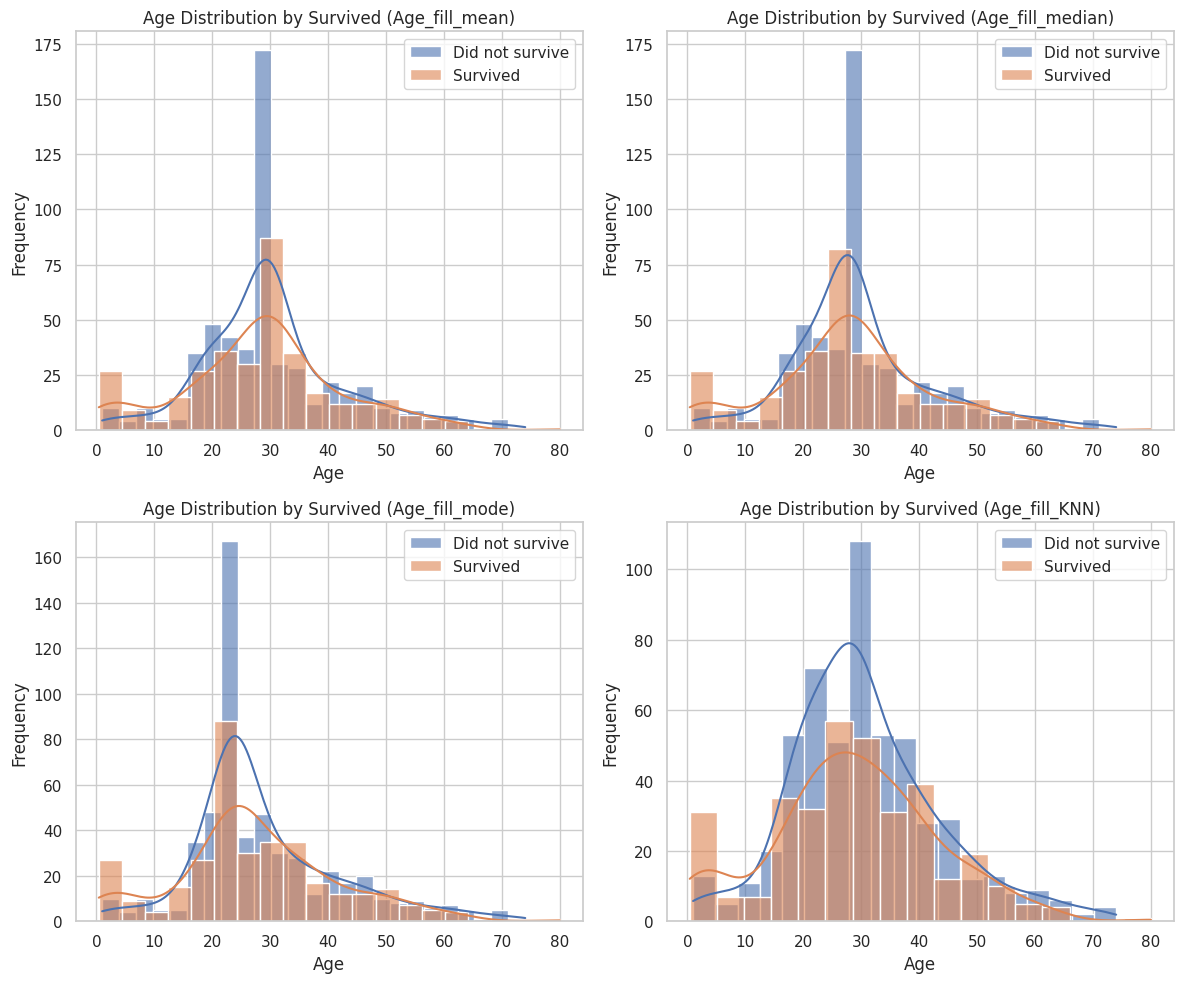

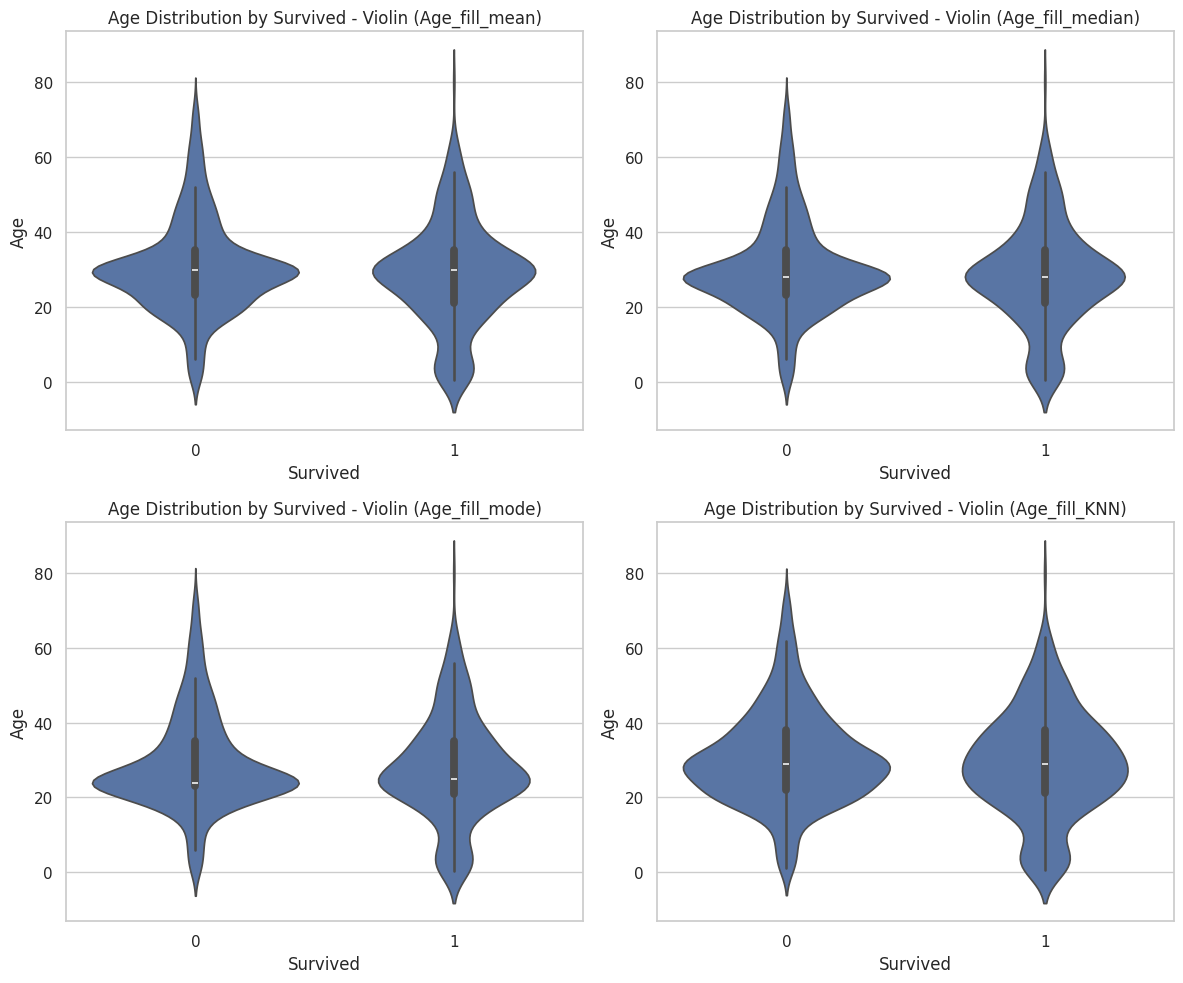

In [8]:
# 5. Age visualizations: distribution by Survived for each fill method

age_columns = ['Age_fill_mean', 'Age_fill_median', 'Age_fill_mode', 'Age_fill_KNN']

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for idx, age_col in enumerate(age_columns):
    ax = axes[idx]
    sns.histplot(data=df[df['Survived'] == 0], x=age_col, label='Did not survive', alpha=0.6, ax=ax, kde=True)
    sns.histplot(data=df[df['Survived'] == 1], x=age_col, label='Survived', alpha=0.6, ax=ax, kde=True)
    ax.set_title(f'Age Distribution by Survived ({age_col})')
    ax.set_xlabel('Age')
    ax.set_ylabel('Frequency')
    ax.legend()

plt.tight_layout()
plt.show()

# Also show violin plots for better comparison
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for idx, age_col in enumerate(age_columns):
    ax = axes[idx]
    sns.violinplot(data=df, x='Survived', y=age_col, ax=ax)
    ax.set_title(f'Age Distribution by Survived - Violin ({age_col})')
    ax.set_ylabel('Age')

plt.tight_layout()
plt.show()

## Analysis and Writeup

### 6a. Appropriate plot types for comparing variables to Survived and why?

- **Pclass (categorical)**: Heatmap or stacked bar chart. A heatmap clearly shows the proportional breakdown of survival outcomes within each class, making it easy to spot differences in survival rates across classes.

- **Fare (continuous)**: Boxplot with strip plot overlay or violin plot. These show the distribution differences between survivors and non-survivors, highlighting median, quartiles, and outliers.

- **Sex (categorical)**: Bar plot showing survival rate. This categorical variable benefits from a simple bar chart displaying the proportion of survivors for each sex category.

- **SibSp (discrete/count)**: Bar plot showing survival rate by number of siblings/spouses. Similar to Sex, this discrete variable works well with bar plots to show survival rates at each level.

- **Parch (discrete/count)**: Bar plot showing survival rate by number of parents/children. Same reasoning as SibSp.

- **Embarked (categorical)**: Bar plot showing survival rate by port of embarkation. Categorical variable best shown with bar charts.

- **Age (continuous)**: Histogram with overlays or violin plot. Histograms with overlaid distributions for both survival outcomes show age differences clearly. Violin plots provide a smooth distribution representation.


### 6b. What would you observe in each visualization type to conclude a predictive relationship?

- **Heatmap**: Strong predictive relationship would show distinct color patterns - survivors concentrated in certain classes (e.g., lighter colors in class 1, darker in class 3).

- **Boxplot**: Distinct separation between the two boxes indicates a predictive relationship. Non-overlapping interquartile ranges or different medians suggest the variable helps predict survival.

- **Bar plots**: Clear differences in bar heights across categories indicate that different category values have different survival rates, suggesting a predictive relationship.

- **Histograms**: Overlaid distributions that are clearly separated or have non-overlapping peaks suggest survivors and non-survivors have different age distributions.

- **Violin plots**: Non-overlapping distributions or significantly different distribution shapes between survival outcomes indicate a predictive relationship.


### 6c. Predictive relationships identified in the data

**Strong predictive relationships:**

1. **Sex**: Extremely strong relationship. The survival rate for females (~74%) is dramatically higher than for males (~19%). This is one of the most obvious predictors. Historically, the "women and children first" protocol during the Titanic evacuation explains this relationship perfectly.

2. **Pclass**: Strong relationship. First-class passengers had 63% survival, second-class 47%, and third-class only 24%. Wealthier passengers had better accommodations, priority access to lifeboats, and more assistance. This reflects the socioeconomic disparities in access to safety.

3. **Fare**: Moderate to strong relationship. The boxplot shows survivors paid higher fares on average, with median fare around £25-30 for survivors vs. much lower for non-survivors. Higher fares correlate with better accommodations and lifeboat access.

**Moderate predictive relationships:**

4. **SibSp (Siblings/Spouses)**: Moderate relationship. Passengers traveling with 1-2 relatives had highest survival (~50%), while those with 0, 4+, or 8 had lower survival (~15-30%). Family connections may have helped during evacuation, but very large groups may have hindered movement.

5. **Parch (Parents/Children)**: Moderate relationship. Passengers with 1-3 parents/children had 50-60% survival, while those with 0, 4+, or 5+ had much lower survival (~20-35%). Similar to SibSp, some family presence helped but too many dependents may have been problematic.

6. **Embarked (Port of Embarkation)**: Weak to moderate relationship. Passengers embarking from Cherbourg (C) had ~55% survival, Southampton (S) ~38%, Queenstown (Q) ~34%. This may reflect class distribution across ports or seating assignments.

**Age (all imputation methods):**

All four imputation methods show a clear relationship: Children (ages 0-15) had much higher survival rates (~50-60%) compared to adult males. The Age_fill_mode shows the sharpest separation, likely because mode heavily fills younger ages. Age_fill_KNN shows more realistic variation. Despite different distributions, all methods show younger age correlates with higher survival - the "women and children first" protocol again.


### 6d. Does the manner of filling missing Age values affect conclusions about Age-Survival relationship?

**Yes, but not fundamentally.** All four imputation methods show the same basic pattern: younger passengers had higher survival rates. However, the degree of clarity differs:

- **Age_fill_mean and Age_fill_median**: Show moderate age differences between survivor groups. Creates artificial clustering around the mean (~29) and median (~29).

- **Age_fill_mode**: Creates the sharpest separation, with a massive spike at mode value. This shows the clearest visual difference but is somewhat artificial since many filled values cluster at one point.

- **Age_fill_KNN**: Shows the smoothest, most realistic distribution. Better preserves natural variation in ages and shows the age-survival relationship most clearly without artificial clustering.

**Conclusion**: The core relationship (children survived more) persists across all methods, but KNN imputation provides the most honest representation. The other methods' artificial clustering could overstate the effect for specific age values while potentially underestimating real variation.


### 6e. PassengerID and Cabin transformations

**PassengerID**: This is just a unique identifier with no intrinsic information about survival. The sequential numbering likely reflects the order passengers boarded or were listed, which could correlate with their assigned deck/location (and thus lifeboat access).
- **Transformation**: Could encode information about boarding sequence or hypothesize cabin location patterns. However, it's likely better to exclude it since survival information comes from Pclass, Fare, and location, which we already have.

**Cabin**: This variable contains valuable information about passenger location on the ship, which directly affected lifeboat access. However, it's categorical with many values (too many distinct cabins) and has substantial missing data.
- **Transformation**: Extract the deck letter (A, B, C, D, E, F, G) from the cabin letter. Deck location determines lifeboat assignment - upper decks had faster access to lifeboats. This categorical variable would be useful since higher decks (A, B, C) likely had better survival chances than lower decks (F, G).


### 6f. Which variables to include in machine learning model and is visual predictiveness necessary/sufficient?

**Variables to include:**

Essential: Sex, Pclass, Fare

Recommended: Age (using KNN imputation), Embarked

Optional: SibSp, Parch (moderate predictiveness)

Exclude: PassengerID, Name, Ticket

**Visual predictiveness vs. actual predictiveness:**

A plot that appears "predictive" is **neither necessary nor sufficient**:  
- **Not sufficient**: A plot might show visual separation due to data artifacts, noise, or confounding variables. A variable's visual relationship with Survived may disappear when controlling for other variables (confounding). For example, Embarked's apparent relationship might be explained entirely by Pclass distribution across ports.

- **Not necessary**: Some important predictive relationships are subtle and don't appear dramatically in visualizations. Interaction effects (e.g., Age × Sex) are real and important but hard to see in univariate plots. Also, weak correlations that are statistically significant can be hidden by noise in plots.

**Best practice**: Use visualizations as an exploratory tool to generate hypotheses, then validate with statistical tests or machine learning models. Include variables based on domain knowledge (what makes theoretical sense) combined with visualization and statistical evidence, not visualization alone.

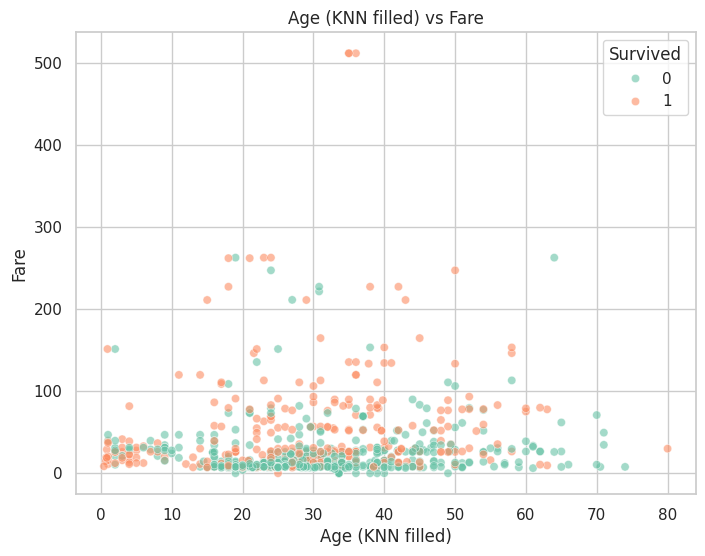

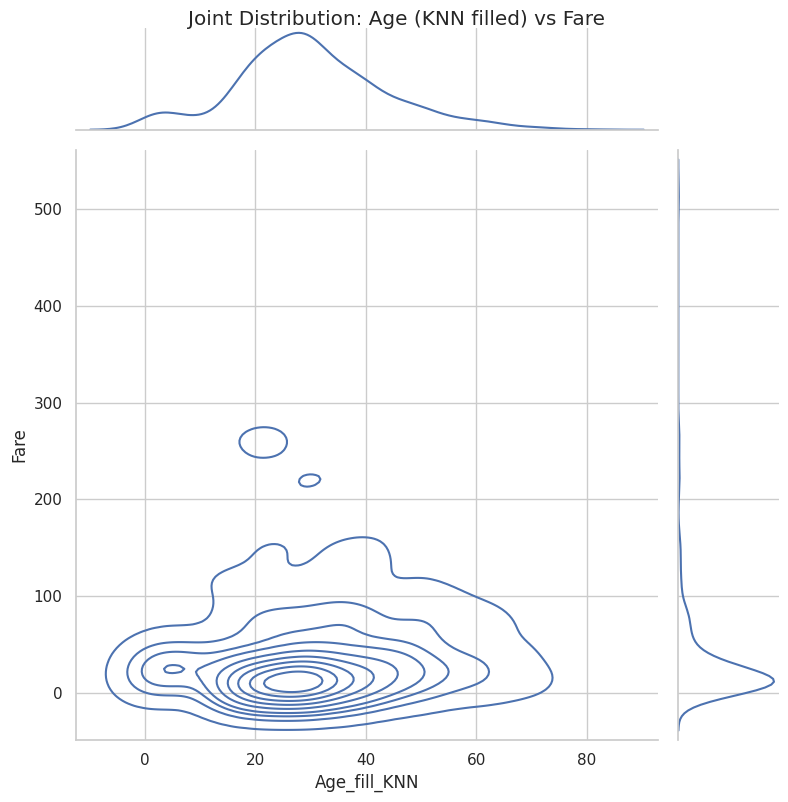

Pearson correlation between Age_fill_KNN and Fare: 0.097


In [9]:
# Correlation analysis: Age_fill_KNN vs Fare

# 2. Scatterplot
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x='Age_fill_KNN', y='Fare', hue='Survived', palette='Set2', alpha=0.6)
plt.title('Age (KNN filled) vs Fare')
plt.xlabel('Age (KNN filled)')
plt.ylabel('Fare')
plt.show()

# 2. Jointplot with KDE
g = sns.jointplot(data=df, x='Age_fill_KNN', y='Fare', kind='kde', height=8)
g.fig.suptitle('Joint Distribution: Age (KNN filled) vs Fare', y=1.00)
plt.show()

# Calculate correlation coefficient
correlation = df['Age_fill_KNN'].corr(df['Fare'])
print(f'Pearson correlation between Age_fill_KNN and Fare: {correlation:.3f}')

## Correlation Analysis: Age vs Fare
### 3a. Do you observe any relationship between Age_fill_KNN and Fare?

**No, there is essentially no linear relationship between Age and Fare.** The Pearson correlation coefficient is 0.097, which is very close to zero and indicates virtually no linear correlation.

**Visual evidence:**
- The scatterplot shows points scattered randomly across the plot with no clear trend or pattern
- Points with low age can have very high fares (e.g., some young passengers paid £500+)
- Points with high age can have low fares, and vice versa
- The KDE jointplot shows the two variables are independently distributed - their contours are roughly circular/elliptical without a clear diagonal slope

**Why there's no relationship:** Age and Fare measure fundamentally different things. Fare reflects passenger wealth and cabin class (first-class cabins cost more regardless of passenger age), while Age is a demographic variable. A wealthy elderly person might pay the same fare as a wealthy young person, while a poor young person and poor elderly person might both pay minimal fares.

**Given this finding:** Since Age and Fare show almost no correlation (r = 0.097), there is **no reason to exclude either variable** from a machine learning model on the basis of multicollinearity. Both variables can independently contribute predictive information.


### 3b. Why would you not include two correlated variables?

**Reasons to exclude highly correlated variables:**

1. **Redundancy**: If two variables are highly correlated, they essentially contain the same information. Including both adds no additional predictive power while increasing model complexity. A model with just one of the correlated variables will likely perform just as well.

2. **Multicollinearity Problems**: Highly correlated predictors cause multicollinearity, which creates several issues:
   - **Unstable coefficients**: The estimated coefficients become very large, small, or even opposite in sign to what you'd expect, making them unreliable and hard to interpret
   - **High variance**: Small changes in the data can cause large swings in coefficient estimates
   - **Overfitting**: The model may fit noise in the training data rather than true patterns
   - **Reduced generalization**: Poor performance on test/new data

3. **Interpretation difficulty**: If variables are correlated, it becomes unclear which one is actually driving predictions. For example, if Income and Education are highly correlated, you can't tell if prediction comes from earning potential or knowledge level.

4. **Model instability**: For some algorithms (especially linear regression), multicollinearity can make the model numerically unstable. Matrix inversion becomes poorly conditioned.

5. **Feature importance unreliable**: With multicollinearity, feature importance rankings become meaningless. Both variables might show as important, but removing one has little effect.